### **Import Packages**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### **Read binary file**

In [15]:
model_dir = "/home/ivan/Documents/devito_projects/curvilinear_elastic/seam/"
n1, n2 = 1101, 1447              # columns, rows (x, t) for example
vp_model = np.fromfile(model_dir + "vp_seam_dip_626.bin", dtype=np.float32, count=n1*n2)
vp_model = vp_model.reshape(n2, n1)           # shape = (rows, cols)
vp_model = vp_model[512:1024,100:612].T

vs_model = np.fromfile(model_dir + "vs_seam_dip_626.bin", dtype=np.float32, count=n1*n2)
vs_model = vs_model.reshape(n2, n1)           # shape = (rows, cols)
vs_model = vs_model[512:1024,100:612].T

rho_model = np.fromfile(model_dir + "rho_seam_dip_626.bin", dtype=np.float32, count=n1*n2)
rho_model = rho_model.reshape(n2, n1)           # shape = (rows, cols)
rho_model = rho_model[512:1024,100:612].T

print("VP model shape:", vp_model.shape)

VP model shape: (512, 512)


### **Display model**

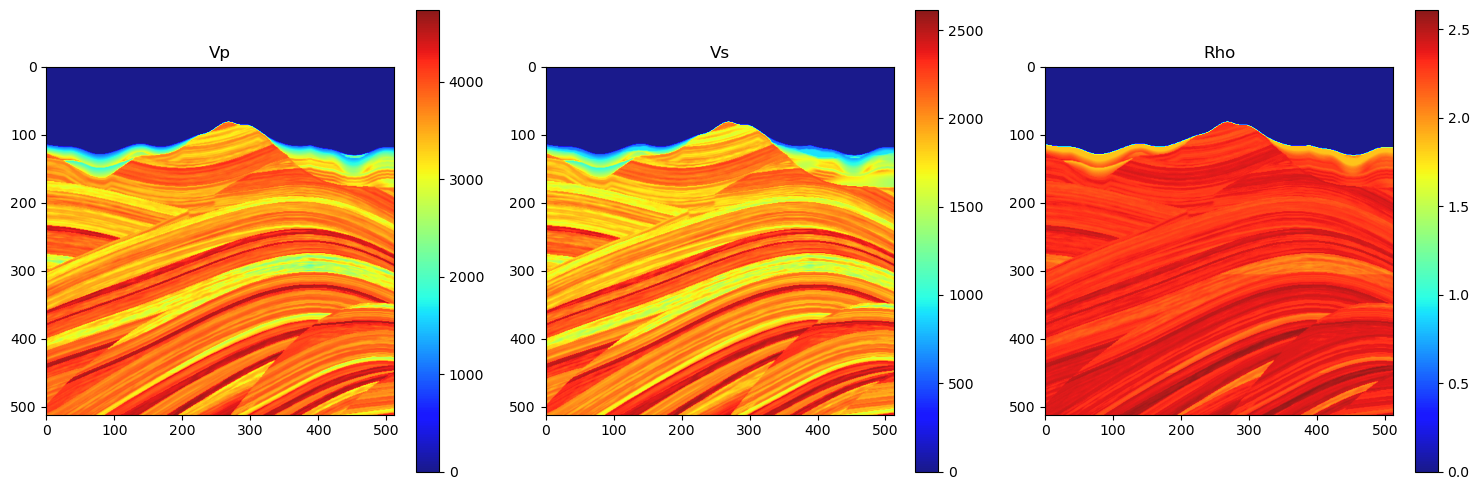

In [16]:
# Set up the subplot figure
nx, nz = vp_model.shape[1], vp_model.shape[0]
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
im1 = axs[0].imshow(vp_model, cmap=plt.cm.jet, alpha=0.9,
                    interpolation='bilinear', origin='lower',
                    extent=(0, nx, 0, nz))
axs[0].invert_yaxis()
axs[0].set_title('Vp')
im2 = axs[1].imshow(vs_model, cmap=plt.cm.jet, alpha=0.9,
                    interpolation='bilinear', origin='lower',
                    extent=(0, nx, 0, nz))
axs[1].invert_yaxis()
axs[1].set_title('Vs')
im3 = axs[2].imshow(rho_model, cmap=plt.cm.jet, alpha=0.9,
                    interpolation='bilinear', origin='lower',
                    extent=(0, nx, 0, nz))
axs[2].invert_yaxis()
axs[2].set_title('Rho')

fig.colorbar(im1, ax=axs[0])
fig.colorbar(im2, ax=axs[1])
fig.colorbar(im3, ax=axs[2])

plt.tight_layout()
plt.show()

### **Minimum and maximum velocity**

In [13]:
print('Vp min:',np.min(vp_model[vp_model>0]),'Vp max:',np.max(vp_model))
print('Vs min:',np.min(vs_model[vs_model>0]),'Vs max:',np.max(vs_model))
print('Rho min:',np.min(rho_model[rho_model>0]),'Rho max:',np.max(rho_model))

Vp min: 593.0564 Vp max: 4737.7344
Vs min: 432.63916 Vs max: 2613.2788
Rho min: 1.8499994 Rho max: 2.6084719


### **Extract Topography**

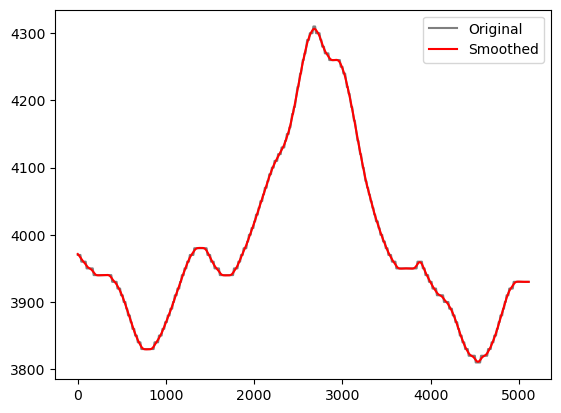

In [24]:
dx, dz = 10.0, 10.0
## Find topography from vp model
topography = (nz-1)*dz-np.argmax(vp_model>0, axis=0)*dz
## Remap topography to get a smoother version
from scipy.interpolate import make_smoothing_spline

x_top = np.arange(topography.size)*dx
spl = make_smoothing_spline(x_top, topography,lam=1e4)
y_top = spl(x_top)
plt.figure()
plt.plot(x_top,topography, 'k', alpha=0.5, label='Original')
plt.plot(x_top, y_top, 'r', label='Smoothed')
plt.legend()
plt.show()

In [34]:
if 1:
    #np.savetxt('./DATA/topseam.dat', np.column_stack((x_top.flatten(), topography.flatten())), fmt='%f')
    np.savetxt('./DATA/topseam.dat', np.column_stack((x_top.flatten(), y_top.flatten())), fmt='%f')
    #np.savetxt('interfaceSEAM.dat', interfaceSEAM.flatten(), fmt='%f')

In [28]:
x_top.flatten().size

512

### **Export model**

In [33]:
vp_model[vp_model==0] = np.min(vp_model[vp_model>0])
vs_model[vs_model==0] = np.min(vs_model[vs_model>0])
rho_model[rho_model==0] = np.min(rho_model[rho_model>0])
# Open a file to write the topography points
if 1:
    with open("./DATA/seam_tomography_model.xyz", "w") as f:
        f.write(f"0.0 0.0 5110 5110\n")
        f.write(f"10.0 10.0\n")
        f.write(f"512 512\n")
        f.write(f"593.0 4738.0 432.0 2614.0 1.85 2.7\n")
        for k in reversed(range(nz)):
            for i in range(nx):
                x = i * dx
                z = k * dz
                vp = vp_model[k,i]
                #vp = 500.0-0.95*z
                vs = vs_model[k,i]
                #vs = 370.0-0.6*z
                rho = rho_model[k,i]
                f.write(f"{x} {(nz-1)*dz - z} {vp} {vs} {rho}\n")


In [15]:
# # Open both files to write
# with open("velocity_points.txt", "w") as points_file, open("import_points.jou", "w") as jou_file:
#     # Write the reset command to the journal file
#     jou_file.write("reset\n")

#     # Iterate over the velocity model and write data to both files
#     point_index = 1
#     jx, jy, jz = 20, 20, 20
#     for k in range(0,Nz,jz):
#         for j in range(0,Ny,jy):
#             for i in range(0,Nx,jx):
#                 x, y, z = i * dx, j * dy, k * dz
#                 velocity = data_3d[Oz+k,Ox+i,Oy+j]
#                 if velocity > 0 :
#                     # Write to velocity_points.txt
#                     points_file.write(f"{x} {y} {z} {velocity}\n")

#                     # Write to import_points.jou to create vertices in Cubit
#                     jou_file.write(f"create vertex x {x} y {y} z {z} name 'v{point_index}'\n")
#                     point_index += 1

In [16]:
import pyvista as pv

# Create a regular 3D grid
dh = 10
x = dh*np.arange(Nx)
y = dh*np.arange(Ny)
z = dh*np.arange(Nz)
Z, X, Y = np.meshgrid(-z, x, y, indexing="ij")  # Create 3D coordinate arrays
print(X.shape)
print(vsx.shape)
# Keep the full grid and mask nonzero values instead of removing points
values = np.where(vsx > 0, vsx, np.nan)  # Replace nonzero values

# Create a structured grid and assign values
grid = pv.StructuredGrid(X, Y, Z)
grid["values"] = values.flatten(order="F")  # Attach values

# Create a structured grid and assign values

# Save to VTK
grid.save("vs_nonzero.vtk")

print("VTK file saved as 'vs_nonzero.vtk'")

(441, 601, 201)
(441, 601, 201)


/home/ivan/Software/anaconda3/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


VTK file saved as 'vs_nonzero.vtk'


In [17]:
Y, X = np.meshgrid(y, x, indexing="ij")  # Structured 2D grid
print(X.shape)
# Define a surface (Z values)
Z = topSEAM # Example surface
print(Z.shape)
# Create a structured surface grid
surface_grid = pv.StructuredGrid(X, Y, Z)
surface_grid["values"] = vstop.flatten(order="F")  # Attach values
# Save as VTK file
surface_grid.save("vs_surface.vtk")

(201, 601)
(201, 601)
